# Análisis Exploratorio de Datos - Datos de consumo en vehículos.txt

Este notebook realiza un análisis exploratorio completo del archivo de datos, utilizando todas las funciones disponibles en `data_explorer.py` para una revisión exhaustiva de los datos.

## 0. Instalación de Dependencias

In [1]:
import subprocess
import sys

# Instalar dependencias requeridas
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

## 1. Importar Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_explorer import DataExplorer
import warnings

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

## 2. Cargar y Explorar Datos

In [3]:
archivo = "auto-mpg.csv"

# Intentar cargar con diferentes delimitadores
try:
    df = pd.read_csv(archivo, sep=',')
    print("✓ Archivo cargado con delimitador COMA")
except:
    try:
        df = pd.read_csv(archivo, sep=';')
        print("✓ Archivo cargado con delimitador PUNTO Y COMA")
    except:
        try:
            df = pd.read_csv(archivo, sep='\\t')
            print("✓ Archivo cargado con delimitador TAB")
        except:
            try:
                df = pd.read_csv(archivo, sep='\\s+')
                print("✓ Archivo cargado con delimitador WHITESPACE")
            except:
                df = pd.read_csv(archivo)
                print("✓ Archivo cargado con delimitador por defecto")

print(f"\\n✓ Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"  Tamaño en memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

✓ Archivo cargado con delimitador COMA
\n✓ Dimensiones: 398 filas × 9 columnas
  Tamaño en memoria: 0.07 MB


## 3. Vista Previa de Datos

In [4]:
print("\\n=== PRIMERAS FILAS ===")
print(df.head(10))

print("\\n=== ÚLTIMAS FILAS ===")
print(df.tail())

print("\\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\\n=== INFORMACIÓN GENERAL ===")
print(df.info())

\n=== PRIMERAS FILAS ===
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   
5  15.0          8         429.0        198    4341          10.0          70   
6  14.0          8         454.0        220    4354           9.0          70   
7  14.0          8         440.0        215    4312           8.5          70   
8  14.0          8         455.0        225    4425          10.0          70   
9  15.0          8         390.0        190    3850           8.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1    

## 4. Crear Instancia de DataExplorer

In [5]:
explorer = DataExplorer(df, verbose=True)

## 5. Resumen Estructural de Datos

In [6]:
resumen_estructural = explorer.get_structural_summary()
print("Resumen Estructural:")
print(resumen_estructural)


=== Structural Summary ===
                    metric   value
                Total rows     398
             Total columns       9
              Memory usage 0.07 MB
           Numeric columns       7
       Categorical columns       0
           Boolean columns       0
          Datetime columns       0
         Free-text columns       0
Unknown/mixed type columns       2
Large dataset (rows >500k)   False
   Wide dataset (cols >50)   False
Resumen Estructural:
                        metric    value
0                   Total rows      398
1                Total columns        9
2                 Memory usage  0.07 MB
3              Numeric columns        7
4          Categorical columns        0
5              Boolean columns        0
6             Datetime columns        0
7            Free-text columns        0
8   Unknown/mixed type columns        2
9   Large dataset (rows >500k)    False
10     Wide dataset (cols >50)    False


## 6. Análisis de Valores Faltantes

In [7]:
analisis_nulos = explorer.analyze_nulls()
print("Análisis de Valores Faltantes:")
print(analisis_nulos)


=== Null Analysis ===
              null_count  null_pct
mpg                    0       0.0
cylinders              0       0.0
displacement           0       0.0
horsepower             0       0.0
weight                 0       0.0
acceleration           0       0.0
model year             0       0.0
origin                 0       0.0
car name               0       0.0
Análisis de Valores Faltantes:
              null_count  null_pct
mpg                    0       0.0
cylinders              0       0.0
displacement           0       0.0
horsepower             0       0.0
weight                 0       0.0
acceleration           0       0.0
model year             0       0.0
origin                 0       0.0
car name               0       0.0


## 7. Análisis de Duplicados

In [8]:
analisis_duplicados = explorer.analyze_duplicates()
print("Análisis de Duplicados:")
for key, value in analisis_duplicados.items():
    print(f"  {key}: {value}")


=== Duplicate Analysis ===
  Full duplicate rows: 0
Análisis de Duplicados:
  full_duplicates: 0
  id_duplicates: None
  duplicated_ids: None


## 8. Detección de Variables con Baja Varianza

In [9]:
bajo_varianza = explorer.detect_low_variance()
print(f"Variables con baja varianza detectadas: {len(bajo_varianza)}")
if bajo_varianza:
    print("Columnas:", bajo_varianza)


=== Low Variance Detection ===
  No low-variance columns detected.
Variables con baja varianza detectadas: 0


## 9. Detección de Outliers

In [10]:
outliers_df = explorer.detect_outliers()
print(f"Total de outliers detectados: {len(outliers_df)}\\n")
if len(outliers_df) > 0:
    print(outliers_df.head(10))


=== Outlier Detection ===
  Method: iqr, threshold: 1.5
              n_outliers  pct_outliers  lower_bound  upper_bound
column                                                          
mpg                    1          0.25        0.250       46.250
cylinders              0          0.00       -2.000       14.000
displacement           0          0.00     -132.375      498.625
weight                 0          0.00      147.375     5684.375
acceleration           7          1.76        8.800       22.200
model year             0          0.00       64.000       88.000
origin                 0          0.00       -0.500        3.500
Total de outliers detectados: 7\n
              n_outliers  pct_outliers  lower_bound  upper_bound
column                                                          
mpg                    1          0.25        0.250       46.250
cylinders              0          0.00       -2.000       14.000
displacement           0          0.00     -132.375      498.625

## 10. Análisis de Normalidad - Gráficos Q-Q

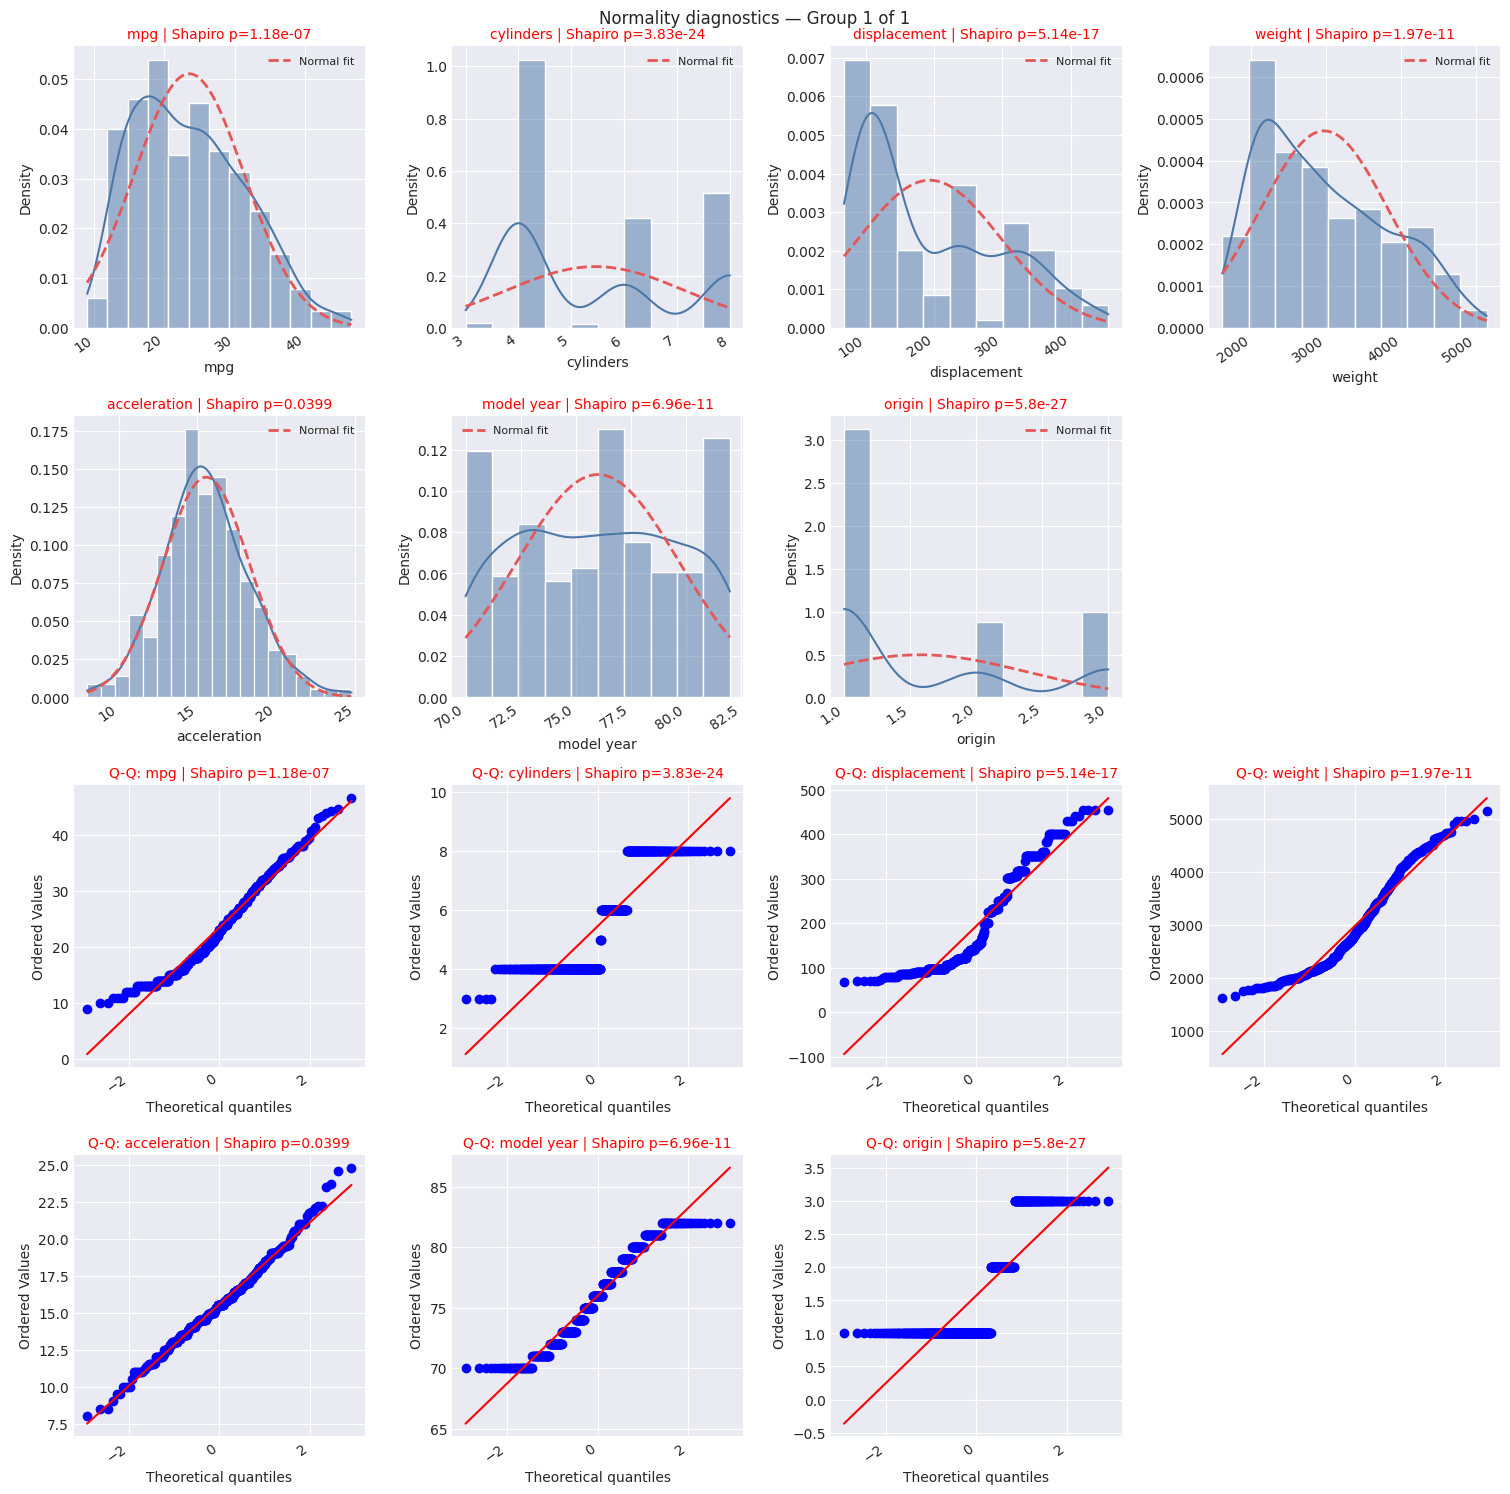

<Figure size 640x480 with 0 Axes>

In [11]:
fig = explorer.plot_normality()
plt.tight_layout()
plt.show()

## 11. Matriz de Correlación

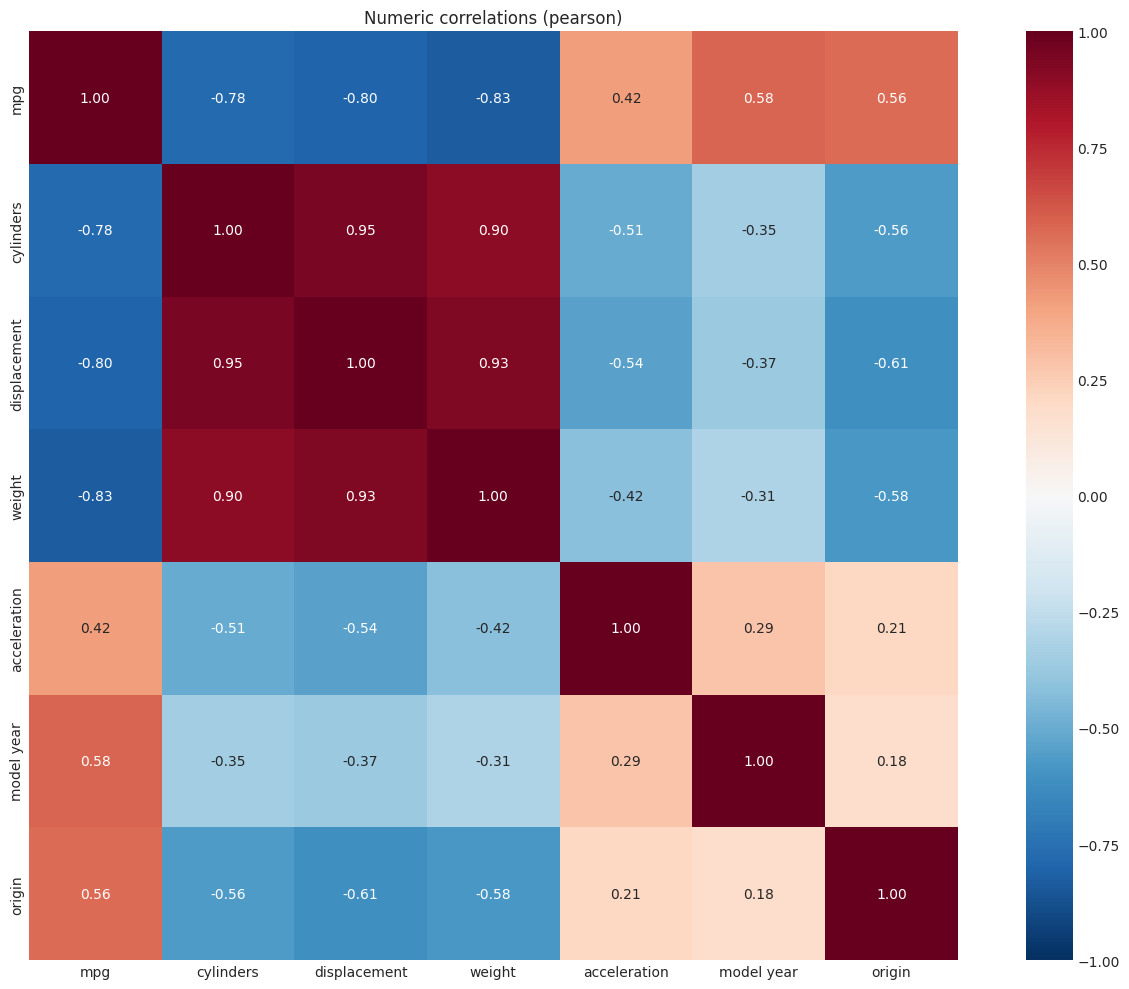

<Figure size 640x480 with 0 Axes>

In [12]:
fig = explorer.plot_correlation_heatmap()
plt.tight_layout()
plt.show()

## 12. Gráficos Scatter de Relaciones Bivariadas

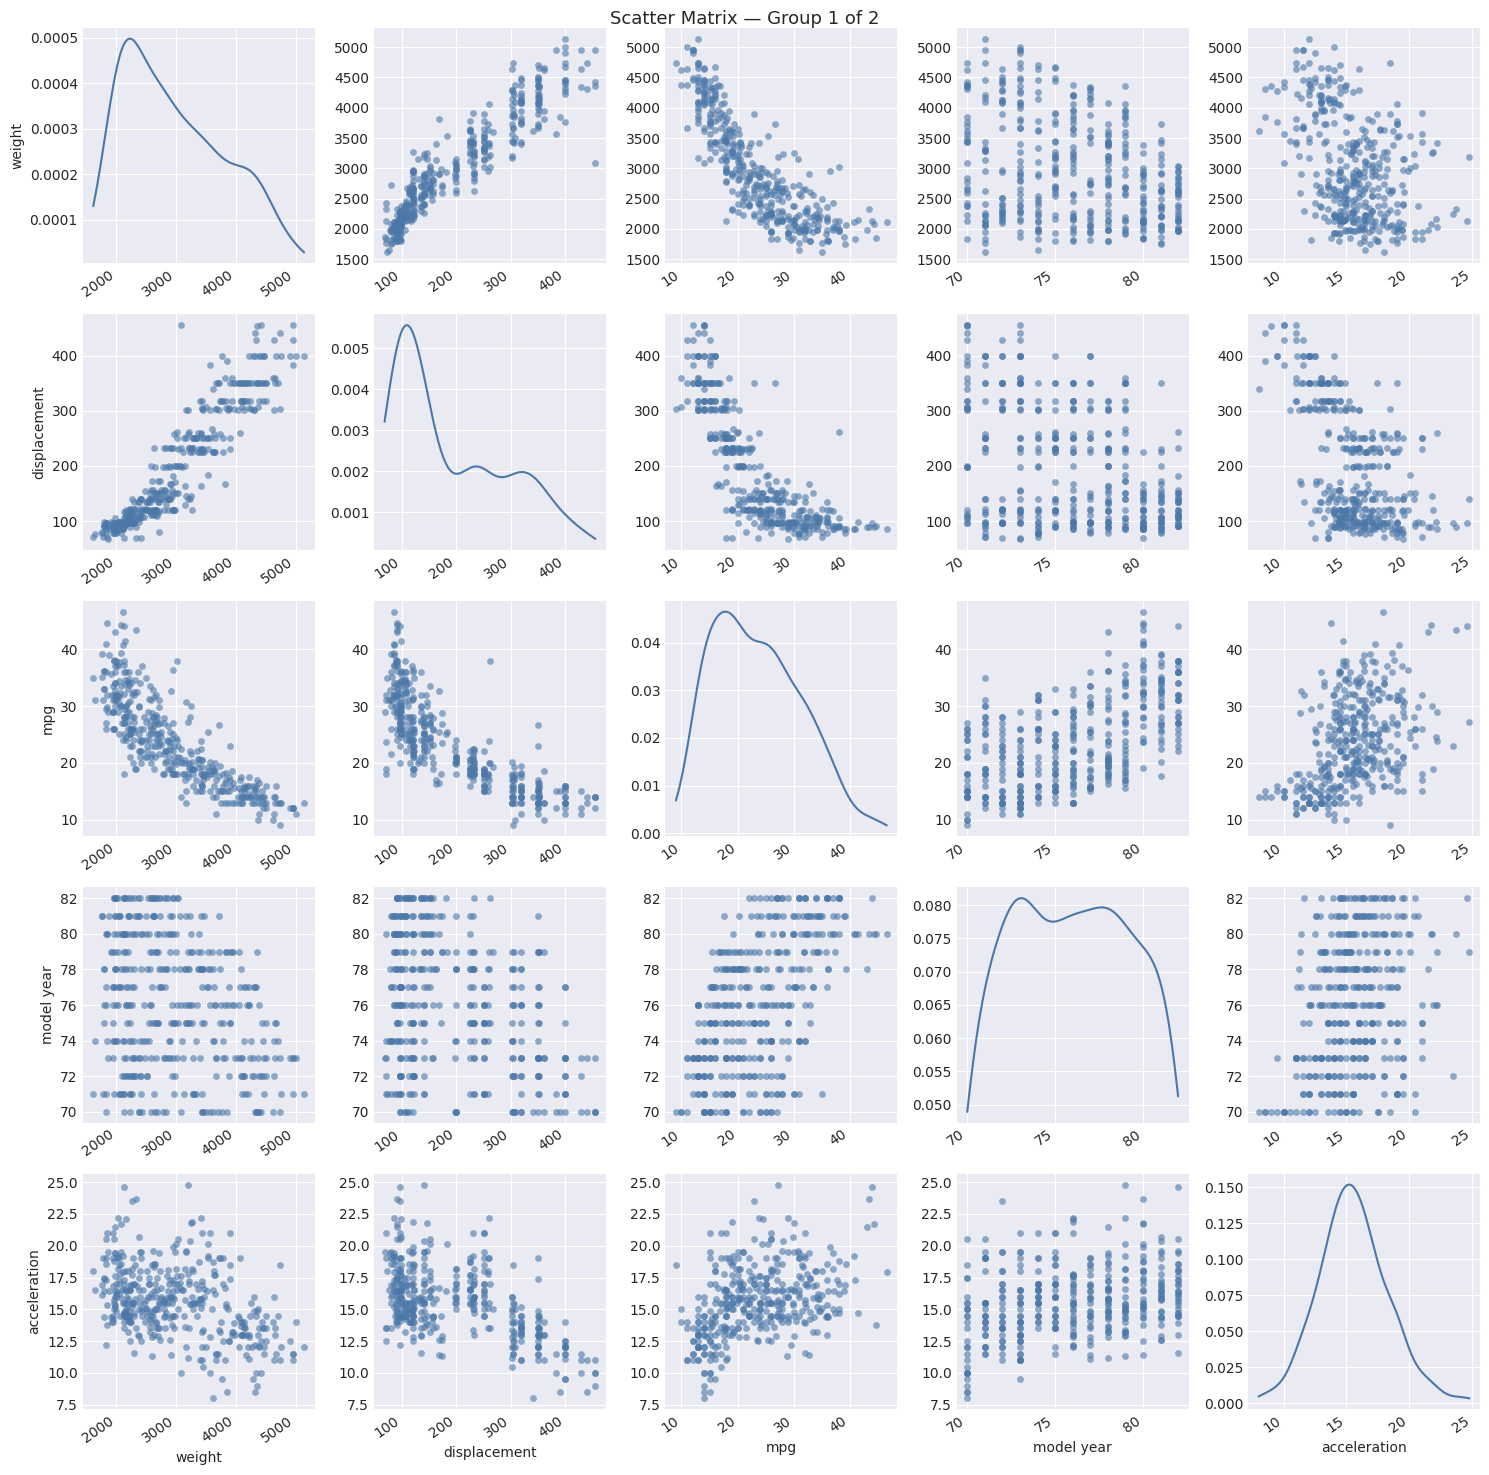

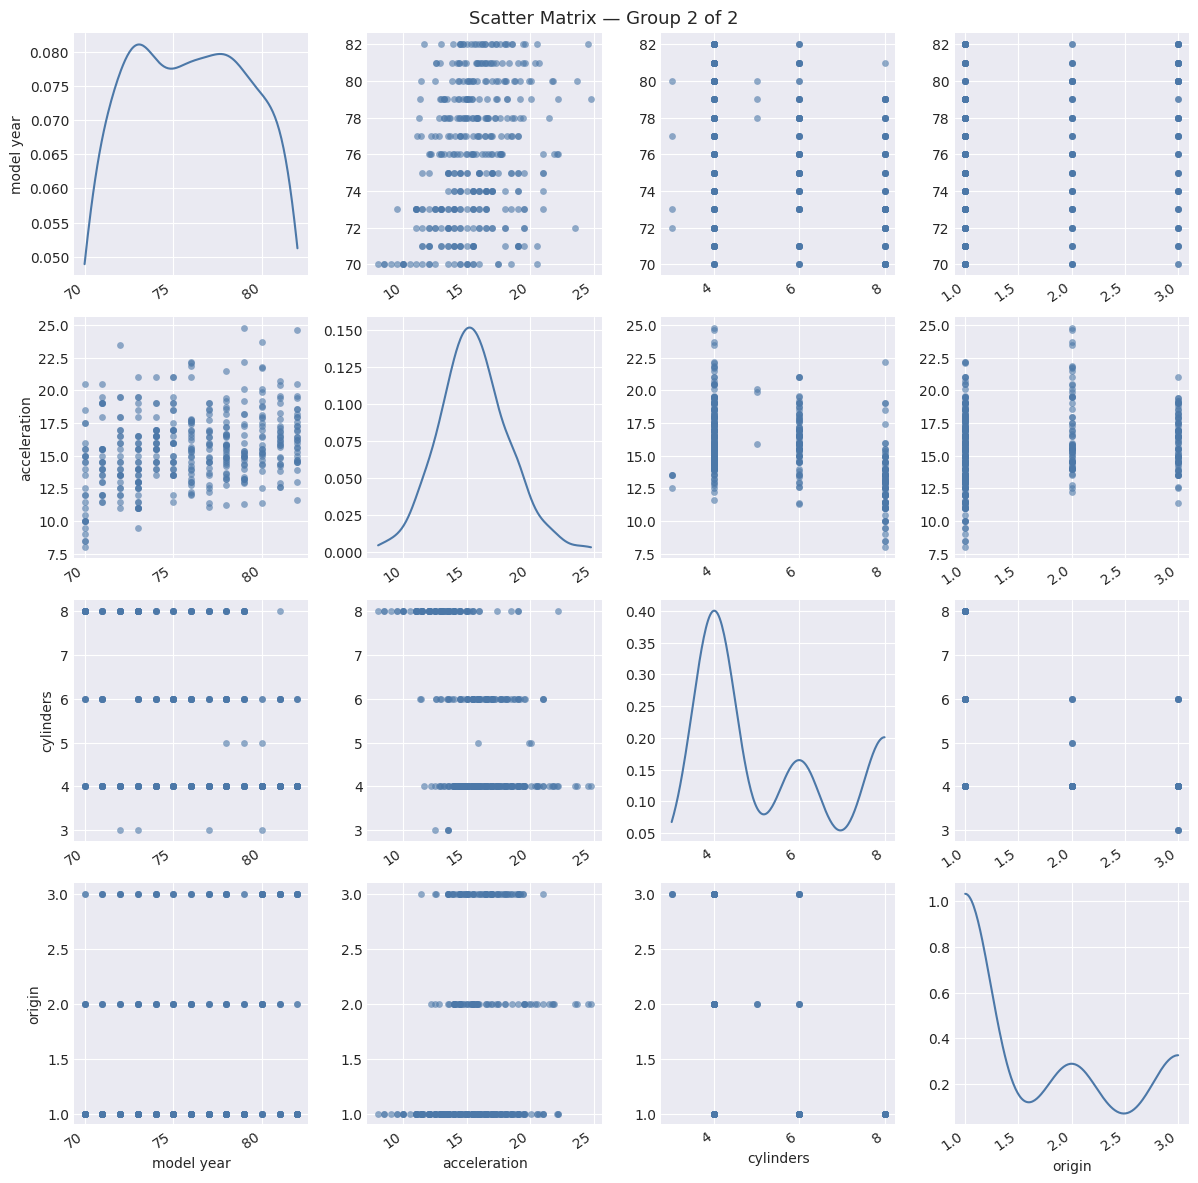

<Figure size 640x480 with 0 Axes>

In [13]:
try:
    fig = explorer.plot_scatter()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Nota: No se pudieron generar scatter plots. Razón: {str(e)[:100]}")

## 13. Resumen de Alertas y Problemas Detectados

In [14]:
alerts_df = explorer.generate_alert_summary()
print(f"Total de alertas: {len(alerts_df)}\\n")
if len(alerts_df) > 0:
    print(alerts_df)


=== Alert Summary ===
severity  category                                                                                                                                               message                                                       affected_columns
 WARNING normality Columns failing normality: ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']. This may affect model assumptions. mpg, cylinders, displacement, weight, acceleration, model year, origin
Total de alertas: 1\n
  severity   category                                            message  \
0  WARNING  normality  Columns failing normality: ['mpg', 'cylinders'...   

                                    affected_columns  
0  mpg, cylinders, displacement, weight, accelera...  


## 14. Pipeline Summary para Downstream Processing

In [15]:
pipeline_summary = explorer.get_pipeline_summary()
print("Pipeline Summary para Downstream Processing:")
print(f"  Número de variables numéricas: {len(pipeline_summary['numeric_cols'])}")
print(f"  Número de variables categóricas: {len(pipeline_summary['categorical_cols'])}")
print(f"  Columnas con valores faltantes: {len(pipeline_summary['null_columns'])}")
print(f"  Columnas de baja varianza: {len(pipeline_summary['low_variance_cols'])}")
print(f"\\nVARIABLES NUMÉRICAS:")
print(pipeline_summary['numeric_cols'][:10])
print(f"\\nVARIABLES CATEGÓRICAS:")
print(pipeline_summary['categorical_cols'][:10])


=== Low Variance Detection ===
  No low-variance columns detected.

=== Outlier Detection ===
  Method: iqr, threshold: 1.5
              n_outliers  pct_outliers  lower_bound  upper_bound
column                                                          
mpg                    1          0.25        0.250       46.250
cylinders              0          0.00       -2.000       14.000
displacement           0          0.00     -132.375      498.625
weight                 0          0.00      147.375     5684.375
acceleration           7          1.76        8.800       22.200
model year             0          0.00       64.000       88.000
origin                 0          0.00       -0.500        3.500

=== Duplicate Analysis ===
  Full duplicate rows: 0

=== Tidy Format Check ===
Dataset appears to be in tidy format.

=== Alert Summary ===
severity  category                                                                                                                                   

## 15. Análisis EDA Completo


=== Tidy Format Check ===
Dataset appears to be in tidy format.

=== Structural Summary ===
                    metric   value
                Total rows     398
             Total columns       9
              Memory usage 0.07 MB
           Numeric columns       7
       Categorical columns       0
           Boolean columns       0
          Datetime columns       0
         Free-text columns       0
Unknown/mixed type columns       2
Large dataset (rows >500k)   False
   Wide dataset (cols >50)   False

=== Null Analysis ===
              null_count  null_pct
mpg                    0       0.0
cylinders              0       0.0
displacement           0       0.0
horsepower             0       0.0
weight                 0       0.0
acceleration           0       0.0
model year             0       0.0
origin                 0       0.0
car name               0       0.0

=== Duplicate Analysis ===
  Full duplicate rows: 0

=== Target Analysis ===
  No target column specified; skippi

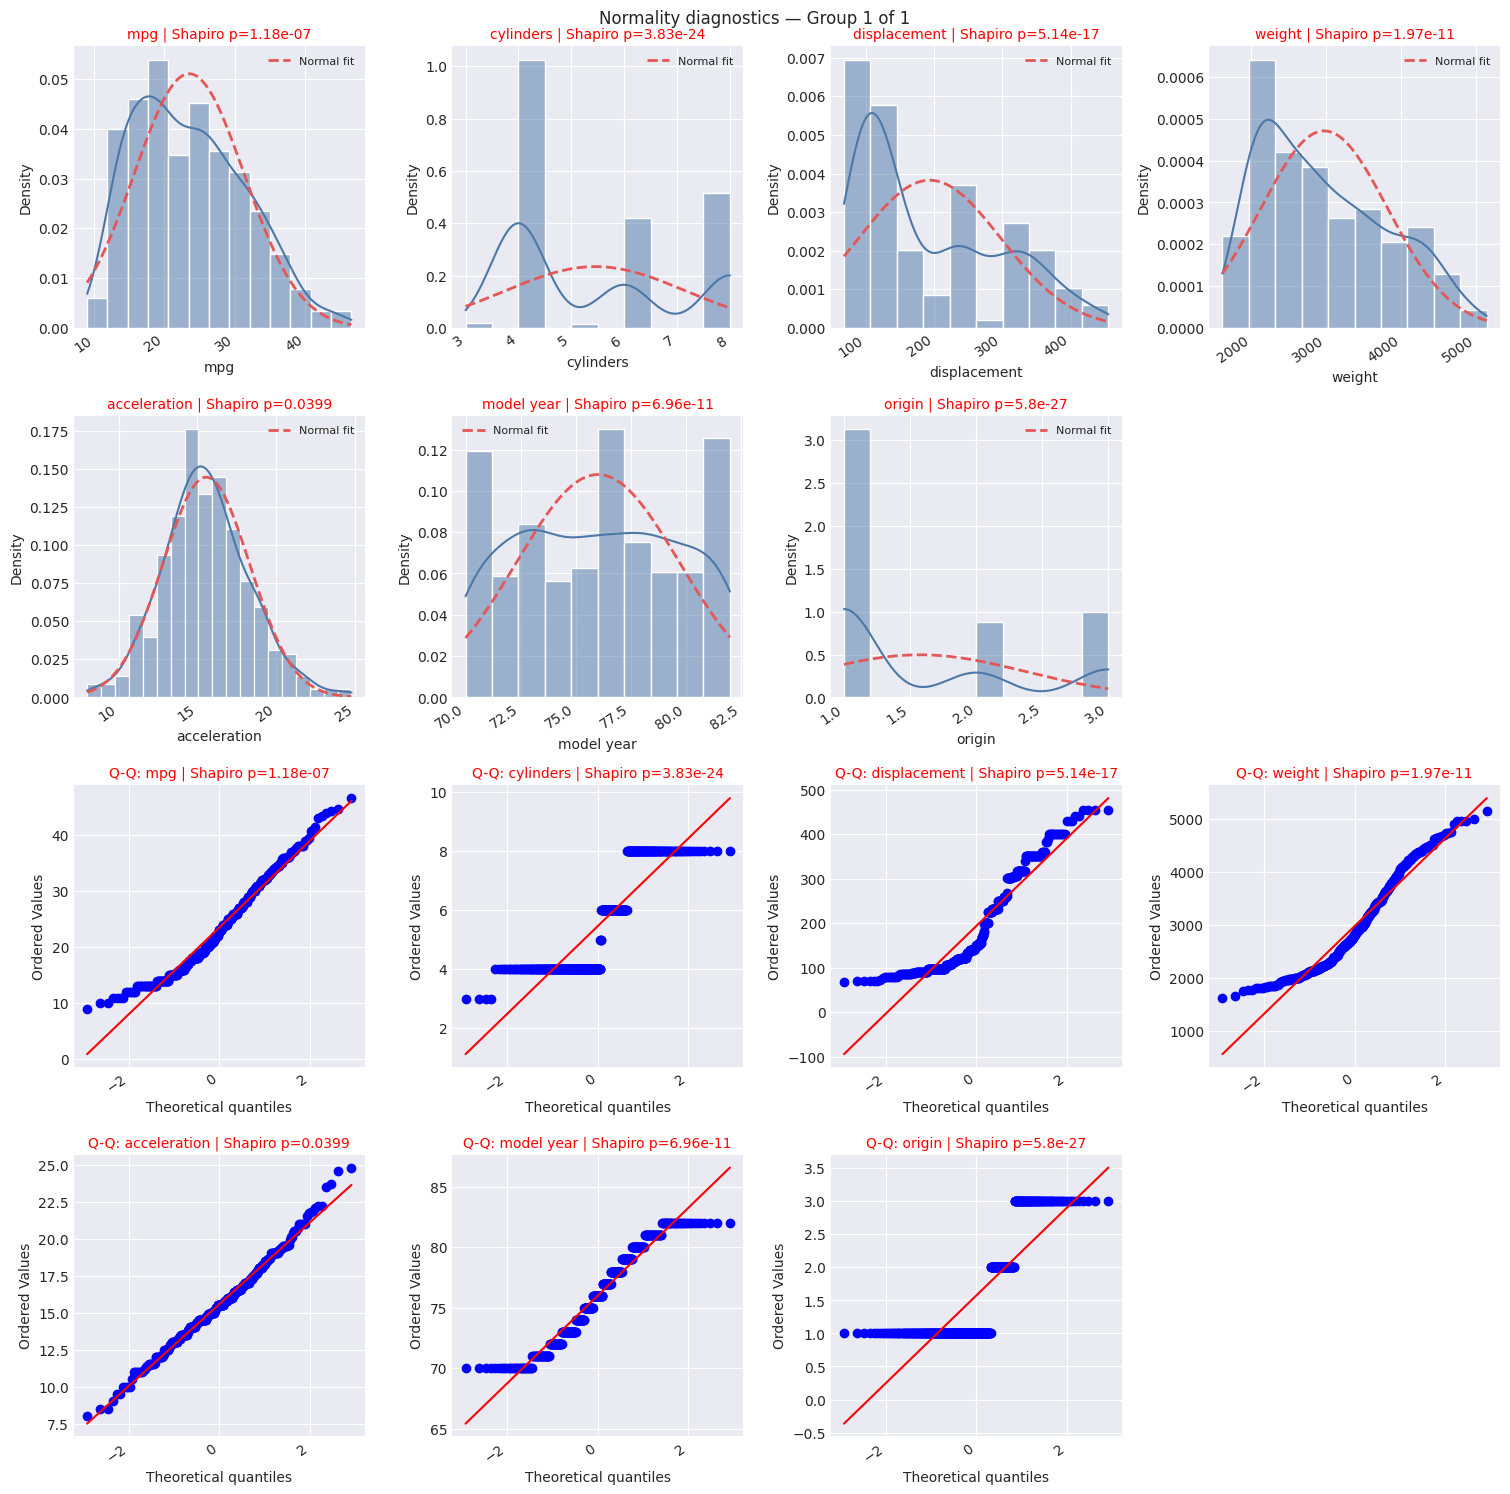

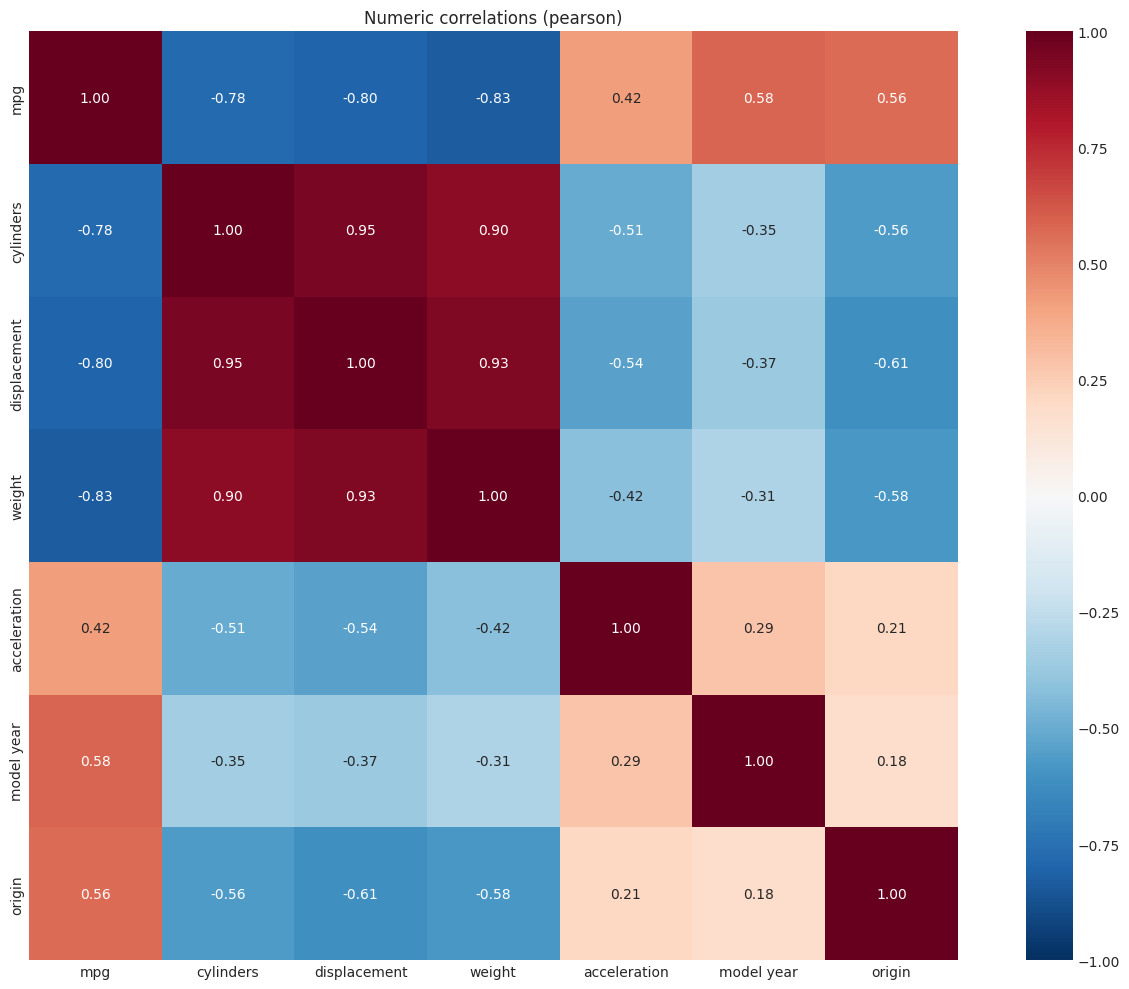


=== Target Correlations ===
  No target column specified; skipping.


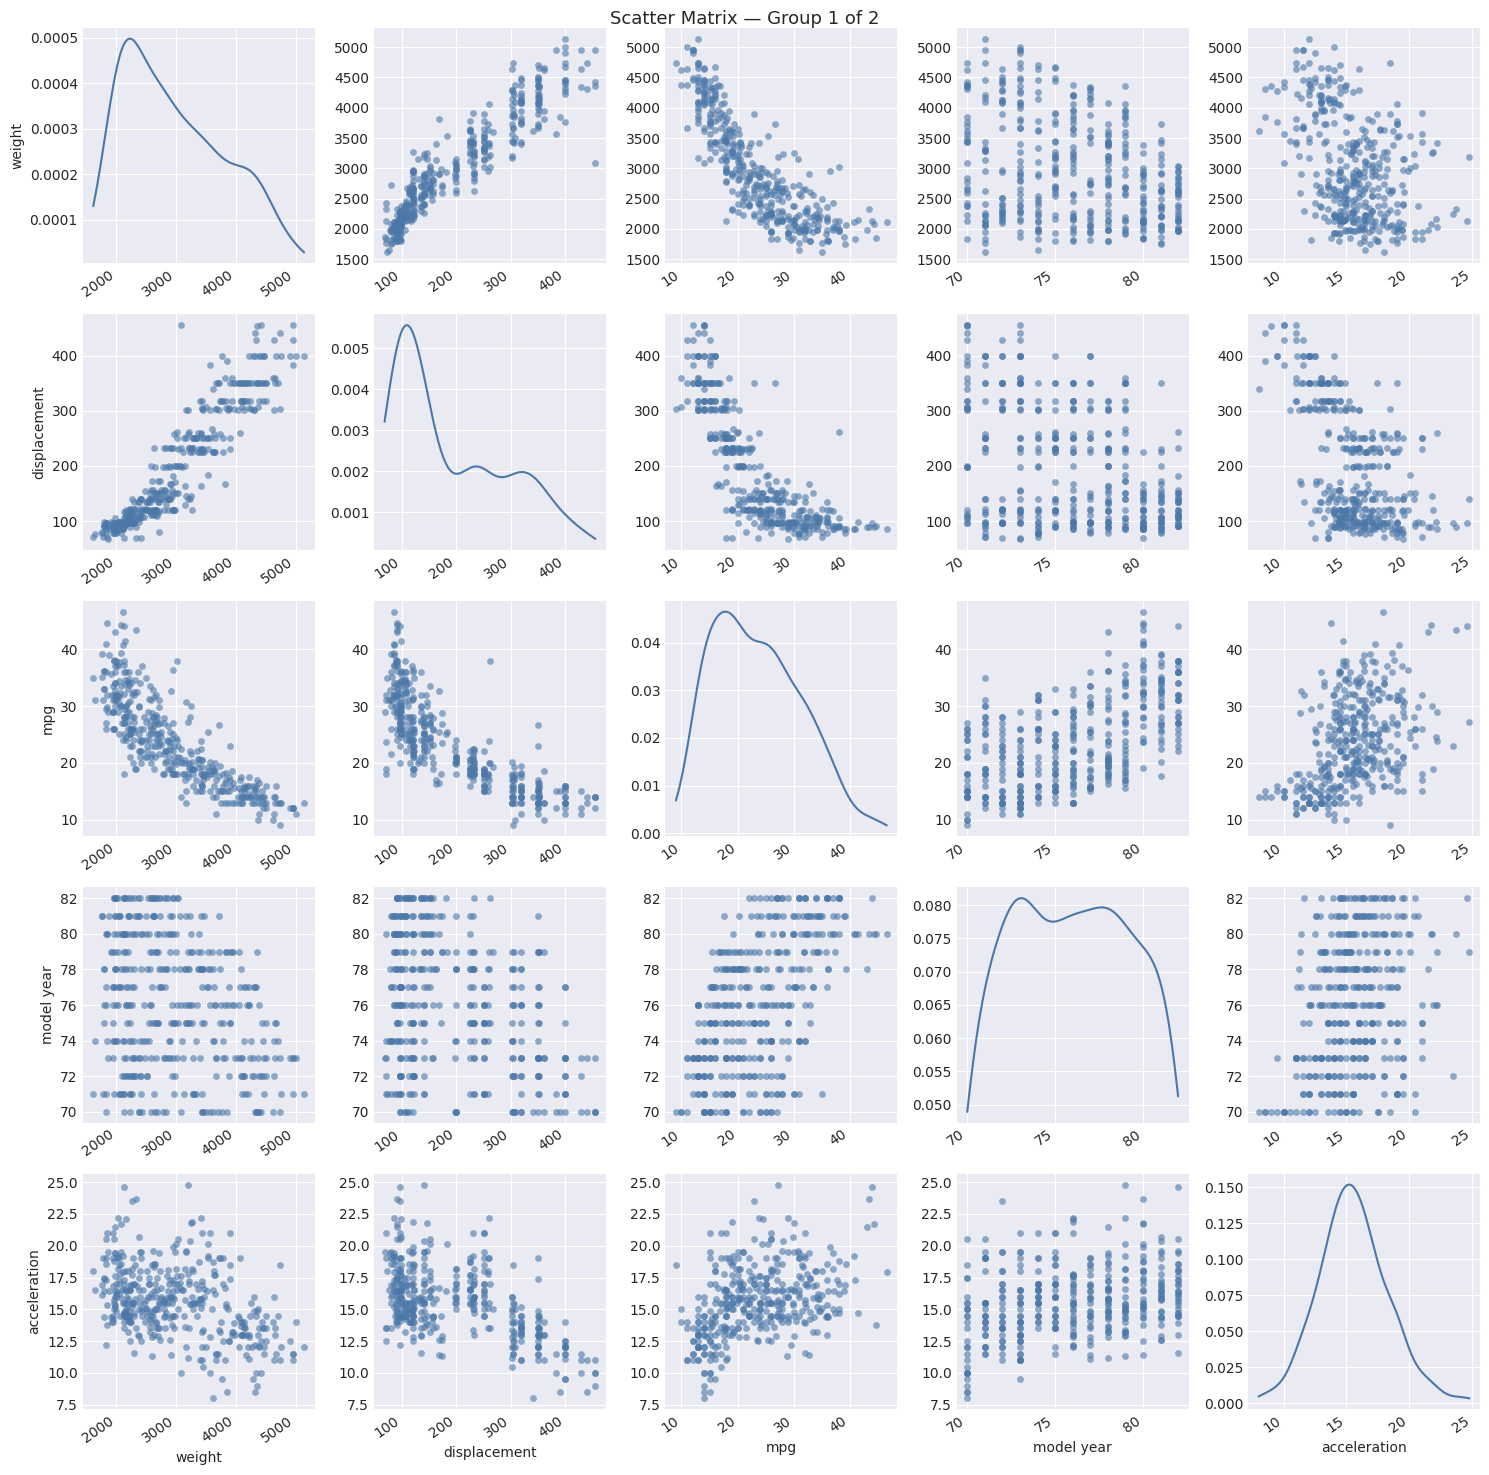

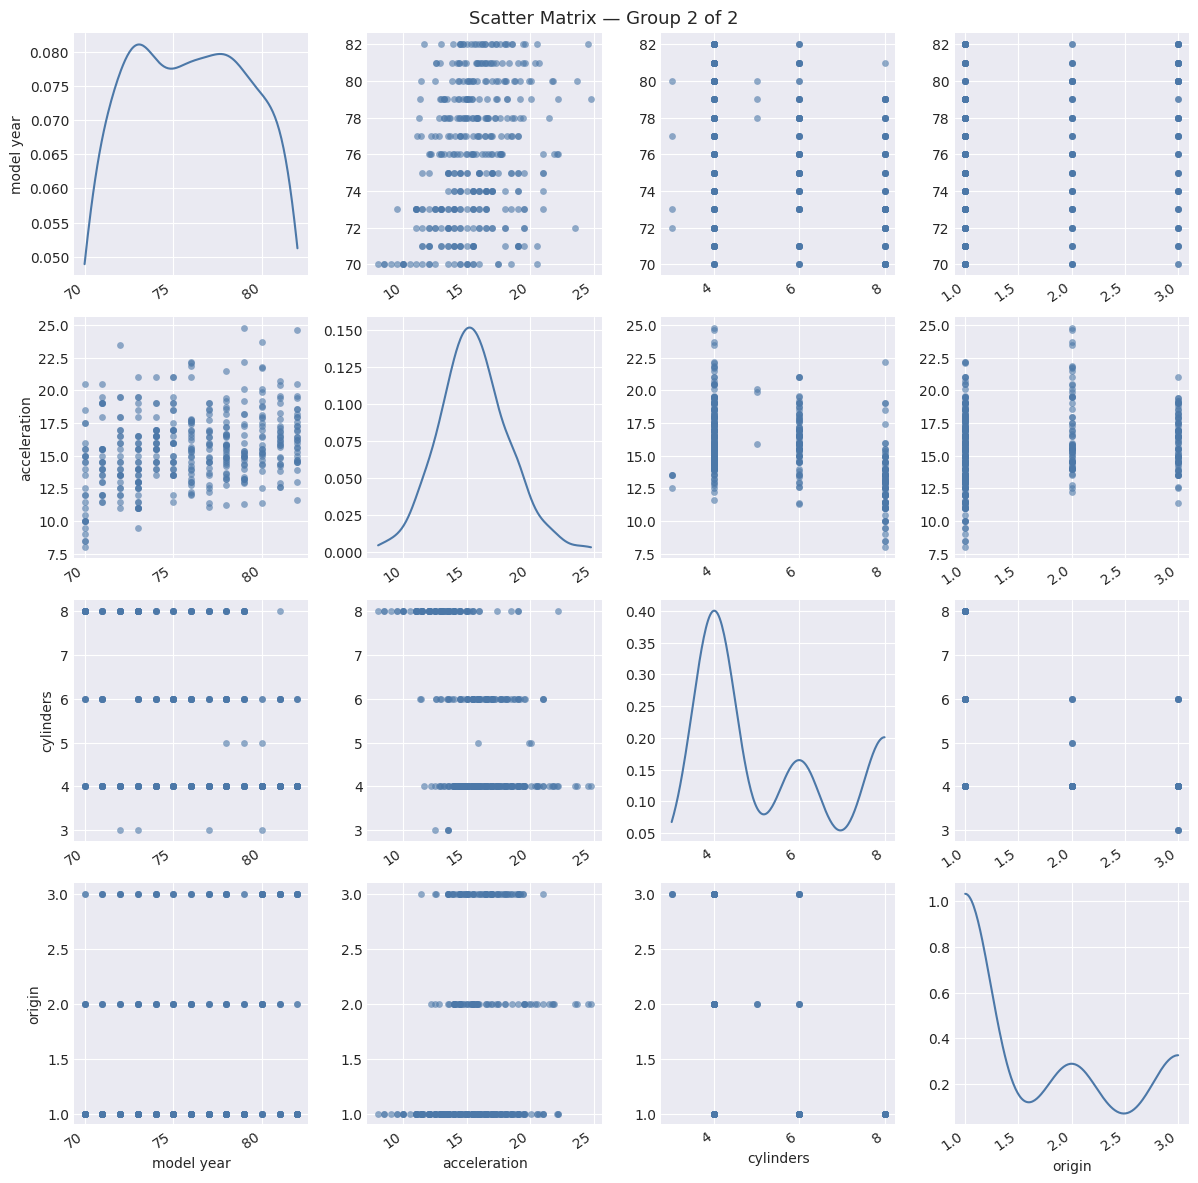

Sweetviz is not installed. Install with: pip install sweetviz

=== Alert Summary ===
severity  category                                                                                                                                               message                                                       affected_columns
 WARNING normality Columns failing normality: ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']. This may affect model assumptions. mpg, cylinders, displacement, weight, acceleration, model year, origin
 WARNING normality Columns failing normality: ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']. This may affect model assumptions. mpg, cylinders, displacement, weight, acceleration, model year, origin

=== Low Variance Detection ===
  No low-variance columns detected.

=== Outlier Detection ===
  Method: iqr, threshold: 1.5
              n_outliers  pct_outliers  lower_bound  upper_bound
colum

In [16]:
full_eda = explorer.run_full_eda()
print("✓ Análisis EDA completo ejecutado exitosamente")
print(f"  Secciones generadas: {len(full_eda)} componentes")